In [1]:
from kan import KAN, create_dataset
from kan.feynman import get_feynman_dataset
import pandas as pd
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
device = "cpu"

In [3]:
seed = 42
symbols, _, func, ranges = get_feynman_dataset("I.12.1")
dataset = create_dataset(func, n_var=len(symbols), normalize_input=True, seed=seed, train_num=1000, test_num=1000, ranges=ranges)

| train_loss: 1.94e-02 | test_loss: 1.81e-02 | reg: 6.84e+00 | : 100%|█| 50/50 [00:03<00:00, 13.92it


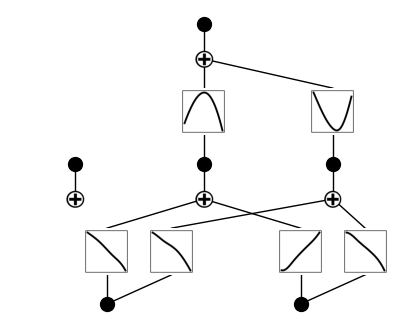

In [4]:
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
# kan =KAN(width=[[len(symbols),0],[2,2],[1,0]], grid=3, k=3, seed=42, device=device)
kan =KAN(width=[2,3,1], grid=3, k=3, seed=seed, device=device, auto_save=False)

kanFitLoss1 = kan.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);
kan.plot(beta=10)

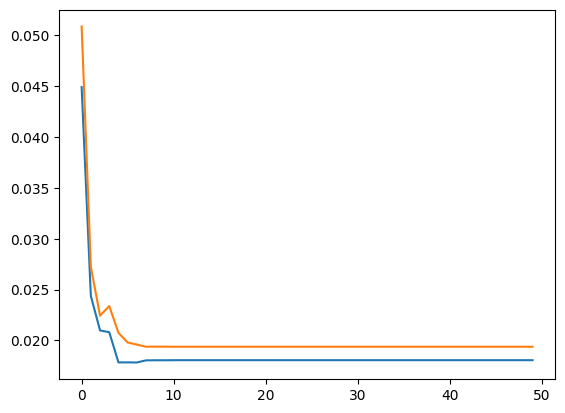

In [5]:
kanLossHistory1test = [x.item() for x in kanFitLoss1['test_loss']]
plt.plot(kanLossHistory1test)
kanLossHistory1train = [x.item() for x in kanFitLoss1['train_loss']]
plt.plot(kanLossHistory1train)
plt.show()

False
False
False
False
False
False


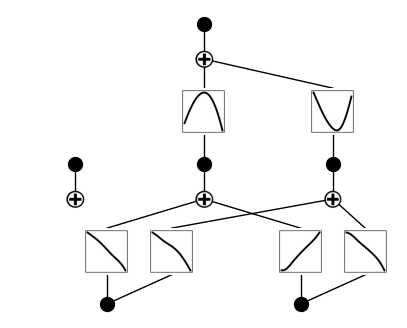

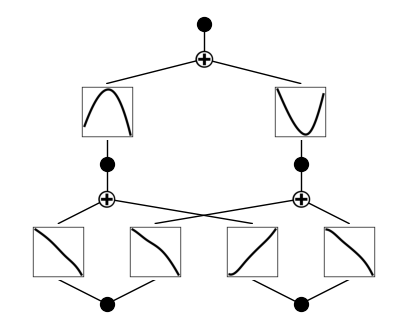

In [ ]:
kan.plot(beta=1000)
kan = kan.prune()
kan.plot(beta=1000)